In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' ## To keep only critical logs
import time

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, models, callbacks, Input

# Check if GPUs are available
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Using Device: GPU ({len(gpus)} available)")
    # Optional: Display the specific name of the GPU
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("Using Device: CPU")

E0000 00:00:1776849250.321704      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776849250.431181      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776849251.364679      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776849251.364722      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776849251.364725      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776849251.364728      55 computation_placer.cc:177] computation placer already registered. Please check linka

Using Device: GPU (2 available)
  - /physical_device:GPU:0
  - /physical_device:GPU:1


### Adding Distributed Strategy 

In [2]:
# Initialize Tensorflow's Mirrored Strategy()
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


I0000 00:00:1776849289.068760      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776849289.074711      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Preparing the dataset

In [3]:
# Set up the dataset paths and labels
data_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
classes = sorted(os.listdir(data_path))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
# Build the list of file paths and labels
file_paths = []
labels = []

for cls_name in classes:
    cls_path = os.path.join(data_path, cls_name)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls_name])

# Basic preprocessing (except augmentations)
def process_path(file_path, label):
    """
    Read the image from the path as uint8 tensor and resize it to 224, 224 and cast it to float32
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)# Decode jpeg/png to a uint8 tensor
    # Resize (equivalent to transforms.Resize)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0 # Normalize to [0, 1] (equivalent to transforms.ToTensor)
    return img, label

## Define the dataset
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))


## Split dataset into training and val as 80% for train and 20% for val
total_samples = len(file_paths)
train_size = int(0.8 * total_samples)
val_size = total_samples - train_size
full_dataset = dataset.shuffle(total_samples, reshuffle_each_iteration=False)
train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)


### Global Batches for Distributed Training

In [4]:
# Adjust batch size for 2 GPUs
base_batch_size = 1024 
GLOBAL_BATCH_SIZE = base_batch_size * strategy.num_replicas_in_sync

## Here we create an augment function and add augmentations to the training dataset
## Both training and val datasets are converted to batches
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label

# We create two config functions, one for train and one for val. This makes sure augmentation is only in train
def configure_train(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(GLOBAL_BATCH_SIZE) # Use the scaled batch size
        .prefetch(tf.data.AUTOTUNE)
    )


def configure_val(ds):
    return (
        ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .batch(GLOBAL_BATCH_SIZE) # Use the scaled batch size
        .prefetch(tf.data.AUTOTUNE)
    )

# Apply to datasets
train_ds = configure_train(train_ds)
val_ds = configure_val(val_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10099157..1.0194337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004980147..0.97884333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.029705286..1.0251011].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031403787..1.041047].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09541164..0.88908803].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.078303516..0.87469125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

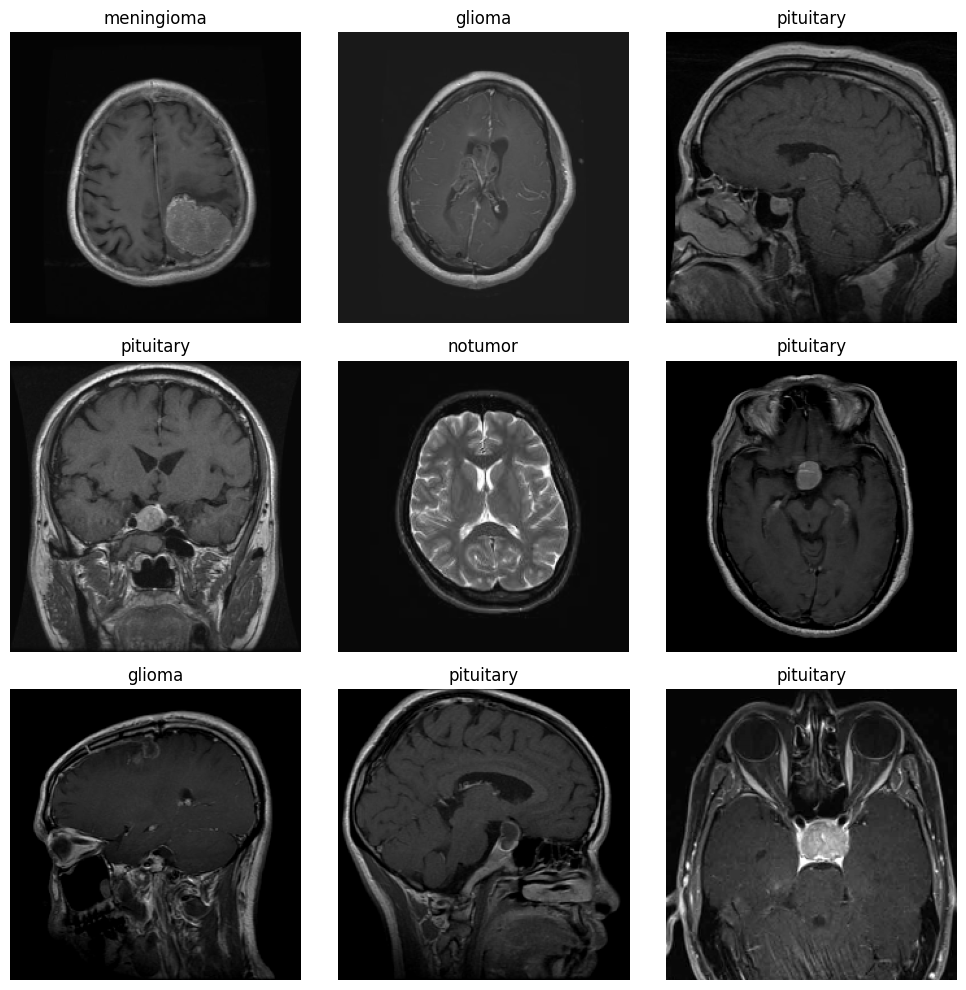

In [5]:
# Grab a batch from the dataset and plot it
images, labels = next(iter(train_ds.take(1)))

# 2. Plot a 3x3 grid
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(classes[labels[i]]) #Using the class list from earlier
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Loading Pretrained ResNet50 inside model strategy scope. Add model construction has to happen inside strategy scope
# All model construction must happen inside the strategy scope
with strategy.scope():
    #Load base model
    base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 

    # Build the model by adding the base model with classification head
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(classes), activation='softmax')(x)
    model = models.Model(inputs=inputs, outputs=outputs) ## inputs and outputs defined functional style

    # Compile the model - happens inside scope
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Define Callbacks
my_callbacks = [
    callbacks.ModelCheckpoint(filepath='best_resnet_model.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.TensorBoard(log_dir='./logs'),
    callbacks.EarlyStopping(monitor='val_loss', patience=10)
]

# Train normally using model.fit. No additional code for mirrored strategy
start_time=time.time()
model.fit(train_ds,validation_data=val_ds,epochs=40,callbacks=my_callbacks)
end_time=time.time()
print ("Training time in seconds: ", (end_time-start_time))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/rep

I0000 00:00:1776849324.842322     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776849324.842343     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2504 - loss: 2.1039  INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 18s/step - accuracy: 0.2512 - loss: 2.0659 - val_accuracy: 0.2518 - val_loss: 1.5487
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - accuracy: 0.2539 - loss: 1.6529 - val_accuracy: 0.2670 - val_loss: 1.4066
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.2920 - loss: 1.4637 - val_accuracy: 0.2554 - val_loss: 1.3181
Epoch 4/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 8s/step - accuracy: 0.2976 - loss: 1.4256 - val_accuracy: 0.4259 - val_loss: 1.2813
Epoch 5/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - accuracy: 0.3499 - loss: 1.3602 - val_accuracy: 0.4259 - val_loss: 1.2331
Epoch 6/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s